In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("../include/output/f1_all_full.csv", sep=";")

# Sección 1: Inspección inicial del dataset

In [47]:
#Validando dimensiones
df.shape

(3754, 57)

### Las primeras filas

In [48]:
#Revisión de columnas
df.head(10)

,DriverId,DriverNumber,TeamId,Year,RoundNumber,DriverPosition_Before,DriverPoints_Before,DriverPoints_Before_DBT_%,TeamPosition_Before,TeamPoints_Before,...,FP_RPM_mean_MED_DBT_%,FP_Brake_mean_MED_DBT_%,FP_LapTime_min_HARD_ABS,FP_LapTime_min_HARD_DBT_%,FP_LapTime_min_WET_ABS,FP_LapTime_min_WET_DBT_%,Races_Before,FinishRate_Before,DriverPoints_Rate_Before,Avg_Position_Gain_Before
0,aitken,89,williams,2020,16,NaN,0.0,100.000000,10.0,0.0,...,0.134533,13.865355,57.187,3.804614,NaN,NaN,0,NaN,NaN,NaN
1,albon,23,toro_rosso,2019,1,0.0,0.0,NaN,0.0,0.0,...,48.016750,76.689333,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
2,albon,23,toro_rosso,2019,2,14.0,0.0,100.000000,8.0,1.0,...,3.114367,18.772003,NaN,NaN,NaN,NaN,1,1.000000,0.000000,-1.000000
3,albon,23,toro_rosso,2019,3,12.0,2.0,95.454545,8.0,3.0,...,150.144569,133.121306,95.771,1.243195,NaN,NaN,2,1.000000,0.040000,1.000000
4,albon,23,toro_rosso,2019,4,13.0,3.0,95.588235,9.0,4.0,...,1.083875,21.001241,NaN,NaN,NaN,NaN,3,1.000000,0.040000,-2.666667
5,albon,23,toro_rosso,2019,5,15.0,3.0,96.551724,9.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,4,1.000000,0.030000,-2.000000
6,albon,23,toro_rosso,2019,6,15.0,3.0,97.321429,9.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5,1.000000,0.024000,-1.600000
7,albon,23,toro_rosso,2019,7,14.0,7.0,94.890511,7.0,16.0,...,0.965377,13.652562,NaN,NaN,NaN,NaN,6,1.000000,0.046667,-1.000000
8,albon,23,toro_rosso,2019,8,15.0,7.0,95.679012,7.0,17.0,...,2.562066,30.521535,NaN,NaN,NaN,NaN,7,0.857143,0.040000,-1.714286
9,albon,23,toro_rosso,2019,9,15.0,7.0,96.256684,8.0,17.0,...,NaN,NaN,68.985,5.274001,NaN,NaN,8,0.875000,0.035000,-2.000000


In [49]:
list(df.columns)

['DriverId',
 'DriverNumber',
 'TeamId',
 'Year',
 'RoundNumber',
 'DriverPosition_Before',
 'DriverPoints_Before',
 'DriverPoints_Before_DBT_%',
 'TeamPosition_Before',
 'TeamPoints_Before',
 'Q_Position',
 'Q_GridPosition',
 'Q1_seconds_ABS',
 'Q2_seconds_ABS',
 'Q3_seconds_ABS',
 'Q_Best_seconds_ABS',
 'Q1_seconds_DBT_%',
 'Q2_seconds_DBT_%',
 'Q3_seconds_DBT_%',
 'Q_Best_seconds_DBT_%',
 'RACE_Position',
 'FP_LapTime_min_INTER_ABS',
 'FP_LapTime_min_SOFT_ABS',
 'FP_LapTime_mean_SOFT_ABS',
 'FP_Throttle_fastlap_ABS',
 'FP_Speed_fastlap_ABS',
 'FP_Speed_max_ABS',
 'FP_RPM_fastlap_ABS',
 'FP_Brake_fastlap_ABS',
 'FP_LapTime_min_INTER_DBT_%',
 'FP_LapTime_min_SOFT_DBT_%',
 'FP_LapTime_mean_SOFT_DBT_%',
 'FP_Throttle_fastlap_DBT_%',
 'FP_Speed_fastlap_DBT_%',
 'FP_Speed_max_DBT_%',
 'FP_RPM_fastlap_DBT_%',
 'FP_Brake_fastlap_DBT_%',
 'FP_LapTime_min_MED_ABS',
 'FP_LapTime_mean_MED_ABS',
 'FP_Throttle_mean_MED_ABS',
 'FP_Speed_mean_MED_ABS',
 'FP_RPM_mean_MED_ABS',
 'FP_Brake_mean_MED_AB

### Tipos de datos

In [50]:
#Cantidad de columnas de cada tipo
df.dtypes.value_counts()

float64    49
int64       6
str         2
Name: count, dtype: int64

### Familias de columnas

In [51]:
# Familias de columnas, según el prefijo anterior al primer guión bajo
df.columns.str.split("_").str[0].value_counts()

FP                32
Q                  4
DriverPoints       3
Q1                 2
Q2                 2
Q3                 2
DriverId           1
DriverNumber       1
TeamId             1
Year               1
RoundNumber        1
DriverPosition     1
TeamPosition       1
TeamPoints         1
RACE               1
Races              1
FinishRate         1
Avg                1
Name: count, dtype: int64

In [52]:
# Familias de columnas, según el prefijo anterior al primer guión bajo
df.columns.str.split("_").str[-1].value_counts()

%               21
ABS             20
Before           8
Position         2
DriverId         1
DriverNumber     1
TeamId           1
Year             1
RoundNumber      1
GridPosition     1
Name: count, dtype: int64

In [53]:
# Las columnas de una familia concreta
df.columns[df.columns.str.endswith("DBT_%")].tolist()

['DriverPoints_Before_DBT_%',
 'Q1_seconds_DBT_%',
 'Q2_seconds_DBT_%',
 'Q3_seconds_DBT_%',
 'Q_Best_seconds_DBT_%',
 'FP_LapTime_min_INTER_DBT_%',
 'FP_LapTime_min_SOFT_DBT_%',
 'FP_LapTime_mean_SOFT_DBT_%',
 'FP_Throttle_fastlap_DBT_%',
 'FP_Speed_fastlap_DBT_%',
 'FP_Speed_max_DBT_%',
 'FP_RPM_fastlap_DBT_%',
 'FP_Brake_fastlap_DBT_%',
 'FP_LapTime_min_MED_DBT_%',
 'FP_LapTime_mean_MED_DBT_%',
 'FP_Throttle_mean_MED_DBT_%',
 'FP_Speed_mean_MED_DBT_%',
 'FP_RPM_mean_MED_DBT_%',
 'FP_Brake_mean_MED_DBT_%',
 'FP_LapTime_min_HARD_DBT_%',
 'FP_LapTime_min_WET_DBT_%']

### Ejemplos de Tipos de Variables

*   **Ordinal:** `Q_Position` (posición en la clasificación)
*   **Categórica:** `TeamId` (identificador del equipo)
*   **Continua:** `FP_LapTime_min_SOFT_ABS`(mínimo tiempo con compuesto blandos en una práctica)

In [54]:
ejemplos_tipos = ['Q_Position', 'TeamId', 'FP_LapTime_min_SOFT_ABS']
df[ejemplos_tipos].head()

,Q_Position,TeamId,FP_LapTime_min_SOFT_ABS
0,18.0,williams,55.670
1,13.0,toro_rosso,84.328
2,12.0,toro_rosso,90.458
3,NaN,toro_rosso,94.600
4,12.0,toro_rosso,103.300


In [55]:
# Cuántos valores distintos toma cada una
df[ejemplos_tipos].nunique()

Q_Position                   22
TeamId                       18
FP_LapTime_min_SOFT_ABS    2956
dtype: int64

In [56]:
# Los valores de una variable ordinal, con su frecuencia
df["Q_Position"].value_counts().sort_index()

Q_Position
1.0     187
2.0     186
3.0     187
4.0     186
5.0     186
6.0     187
7.0     186
8.0     187
9.0     186
10.0    187
11.0    186
12.0    188
13.0    187
14.0    187
15.0    190
16.0    187
17.0    186
18.0    186
19.0    183
20.0    178
21.0     12
22.0     12
Name: count, dtype: int64

# Sección 2: Análisis univariado

In [57]:
df.select_dtypes(include=np.number).describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
DriverNumber,3754.0,28.1,24.5,1.0,10.0,20.0,44.0,99.0
Year,3754.0,2022.0,2.5,2018.0,2020.0,2022.0,2024.0,2026.0
RoundNumber,3754.0,11.1,6.3,1.0,6.0,11.0,16.0,24.0
DriverPosition_Before,3701.0,10.1,6.2,0.0,5.0,10.0,15.0,23.0
DriverPoints_Before,3754.0,52.9,77.8,0.0,2.0,19.0,66.0,549.0
DriverPoints_Before_DBT_%,3572.0,74.7,29.7,0.0,57.8,89.0,97.9,100.0
TeamPosition_Before,3748.0,5.3,3.1,0.0,3.0,5.0,8.0,11.0
TeamPoints_Before,3754.0,106.1,148.7,0.0,8.0,40.5,138.0,822.0
Q_Position,3747.0,10.5,5.8,1.0,6.0,11.0,16.0,22.0
Q_GridPosition,3754.0,10.4,5.9,0.0,5.0,10.0,15.0,22.0


### Comparación de DBT_% de clasificación (cantidad de datos)

Comparamos la cantidad de datos válidos (no nulos) de las columnas `_DBT_%` de la clasificación. Q1 la disputan casi todos los pilotos, mientras que Q2 y Q3 son más restrictivas y, por eso, acumulan menos observaciones.

In [ ]:
quali_dbt_cols = [
    "Q1_seconds_DBT_%",
    "Q2_seconds_DBT_%",
    "Q3_seconds_DBT_%",
    "Q_Best_seconds_DBT_%",
]

resumen = pd.DataFrame({
    "No nulos": [df[c].notna().sum() for c in quali_dbt_cols],
    "Nulos": [df[c].isna().sum() for c in quali_dbt_cols],
    "% completitud": [df[c].notna().mean() * 100 for c in quali_dbt_cols],
}, index=quali_dbt_cols)

display(resumen)

resumen["No nulos"].plot.bar(color="#2B5C8F", edgecolor="white", figsize=(8, 4))
plt.title("Cantidad de datos válidos por columna DBT_% de clasificación")
plt.ylabel("Filas no nulas")
plt.xlabel("Columna")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Comparación de DBT_% de prácticas (cantidad de datos)

Mismo análisis para los tiempos de vuelta de prácticas: `_min_` existe para los 5 compuestos (SOFT, MED, HARD, INTER, WET), mientras que `_mean_` solo para SOFT y MED (los que tienen múltiples vueltas válidas).

In [ ]:
fp_laptime_dbt_cols = [
    "FP_LapTime_min_INTER_DBT_%",
    "FP_LapTime_min_SOFT_DBT_%",
    "FP_LapTime_min_MED_DBT_%",
    "FP_LapTime_min_HARD_DBT_%",
    "FP_LapTime_min_WET_DBT_%",
    "FP_LapTime_mean_SOFT_DBT_%",
    "FP_LapTime_mean_MED_DBT_%",
]

resumen_fp = pd.DataFrame({
    "No nulos": [df[c].notna().sum() for c in fp_laptime_dbt_cols],
    "Nulos": [df[c].isna().sum() for c in fp_laptime_dbt_cols],
    "% completitud": [df[c].notna().mean() * 100 for c in fp_laptime_dbt_cols],
}, index=list(map(lambda x: "_".join(x.split("_")[1:]), fp_laptime_dbt_cols)))

display(resumen_fp)

resumen_fp["No nulos"].plot.bar(color="#009086", edgecolor="white", figsize=(8, 4))
plt.title("Cantidad de datos válidos por columna DBT_% de prácticas")
plt.ylabel("Filas no nulas")
plt.xlabel("Columna")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [58]:
# Asimetría y curtosis de las columnas numéricas
df.select_dtypes(include=np.number).agg(["skew", "kurt"]).round(2).T.sort_values(by="kurt", ascending=False)

,skew,kurt
Q2_seconds_DBT_%,30.17,1203.62
FP_LapTime_min_MED_DBT_%,18.72,476.11
FP_LapTime_min_SOFT_DBT_%,18.15,377.55
FP_LapTime_mean_MED_DBT_%,15.44,360.56
Q1_seconds_DBT_%,12.64,349.15
FP_LapTime_mean_SOFT_DBT_%,15.14,292.99
Q3_seconds_DBT_%,9.74,161.50
FP_Speed_max_DBT_%,11.93,141.07
FP_Speed_fastlap_DBT_%,11.80,138.13
FP_RPM_fastlap_DBT_%,11.36,131.71


* Las mayorias de las columnas DBT_% (distancia porcentual al mejor) presenta una alta curtosis pero si analizamos el caso de `Q2_seconds_DBT_%`, `FP_LapTime_min_MED_DBT_%`,`FP_LapTime_min_SOFT_DBT_%` y `FP_LapTime_mean_MED_DBT_%` respecto a los valores que no son DBT_% de esos mismos datos, es decir, `Q2_seconds_ABS`, `FP_LapTime_min_MED_ABS`,`FP_LapTime_min_SOFT_ABS` y `FP_LapTime_mean_MED_ABS` vemos que:    

Columna|Skewness|Kurtosis|Mínimo (min)|Percentil 75 (75%)|Máximo (max)  
|---|---|---|---|---|---|
Q2_seconds_DBT_%|23.85|824.33|0.0|1.1|61.7
Q2_seconds_ABS|0.42|-0.04|53.6|91.5|126.7
FP_LapTime_min_MED_DBT_%|16.59|398.64|0.0|2.2|68.6
FP_LapTime_min_MED_ABS|0.26|-0.04|54.6|93.5|144.0
FP_LapTime_min_SOFT_DBT_%|17.12|346.33|0.0|1.7|66.3
FP_LapTime_min_SOFT_ABS|0.23|-0.02|54.1|92.1|139.7
FP_LapTime_mean_MED_DBT_%|13.35|287.07|0.0|3.0|70.3
FP_LapTime_mean_MED_ABS|0.25|-0.08|55.6|95.2|146.9

  - Los tiempos absolutos responden a la diversidad de los circuitos: La diferencia entre el mínimo y el máximo refleja simplemente las distintas longitudes del calendario. Dentro de cada Gran Premio individual, los tiempos se agrupan de forma simétrica alrededor de la media.
  - La métrica DBT_% elimina la escala del circuito pero introduce una cota inferior rígida: al dividir la distancia al mejor por el mejor tiempo de la sesión, el límite en 0% actúa como una pared infranqueable a la izquierda. La inmensa mayoría de las observaciones quedan comprimidas en un rango muy estrecho de porcentajes bajos, pero la cola derecha se dispara en casos puntuales.

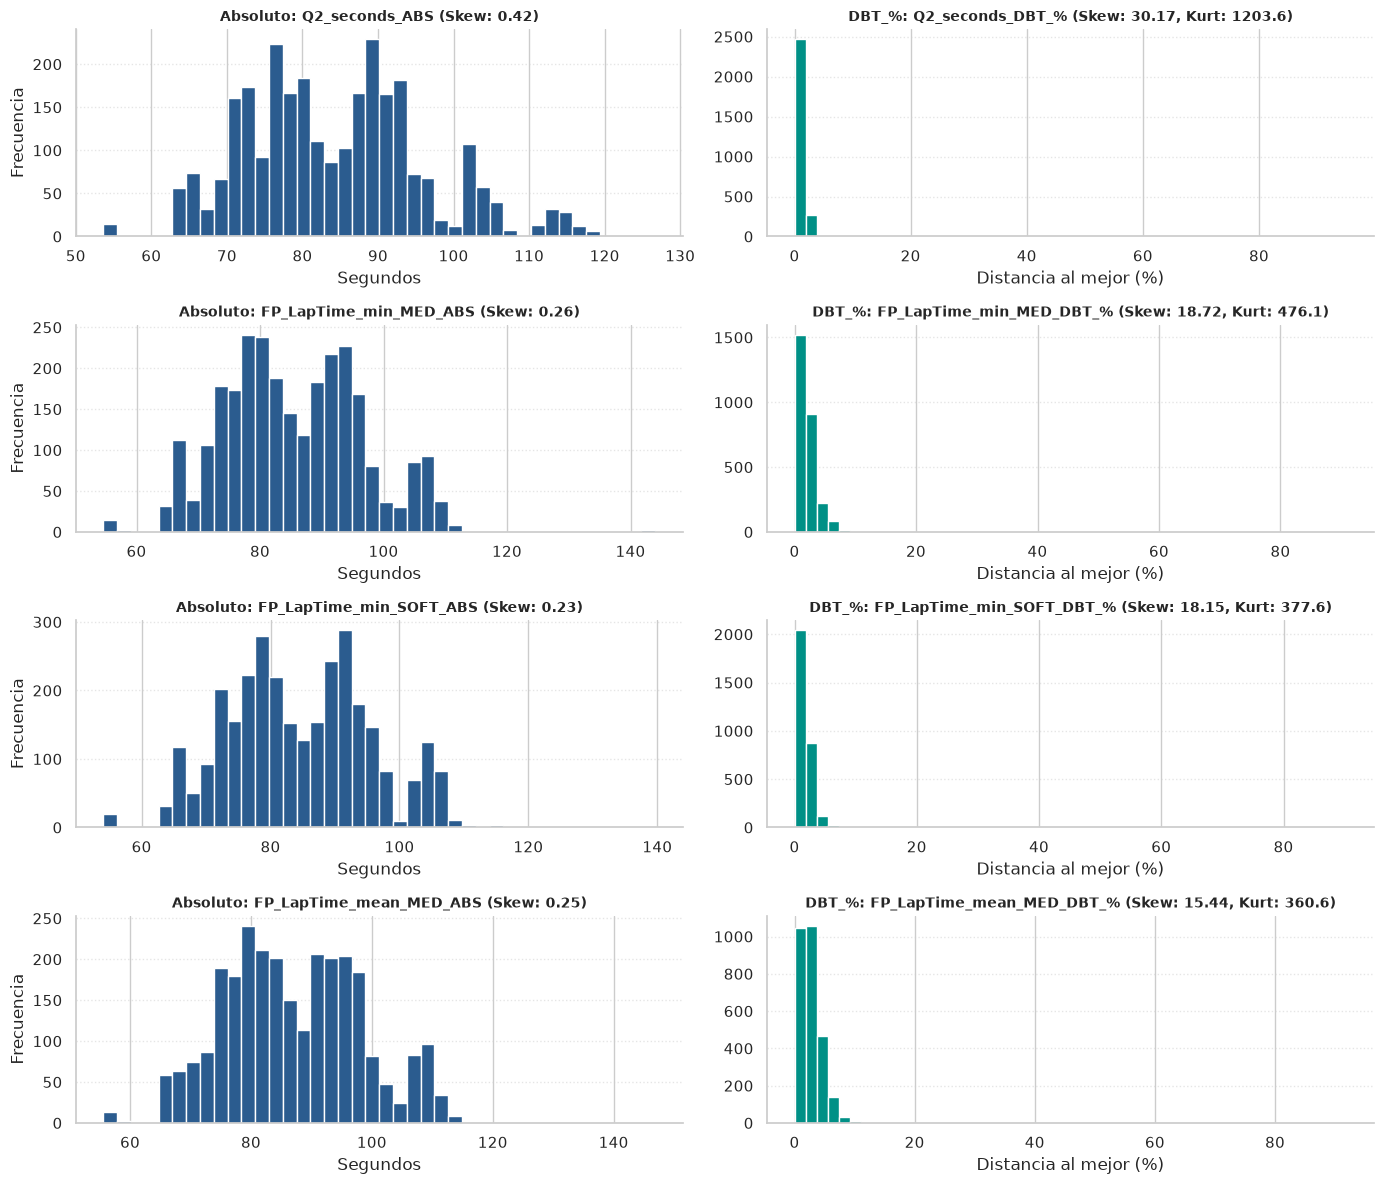

In [59]:
# Par de columnas: (Absoluta vs DBT%)
pairs = [
    ("Q2_seconds_ABS", "Q2_seconds_DBT_%"),
    ("FP_LapTime_min_MED_ABS", "FP_LapTime_min_MED_DBT_%"),
    ("FP_LapTime_min_SOFT_ABS", "FP_LapTime_min_SOFT_DBT_%"),
    ("FP_LapTime_mean_MED_ABS", "FP_LapTime_mean_MED_DBT_%")
]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for i, (col_abs, col_dbt) in enumerate(pairs):
    # --- Columna Absoluta (Izquierda) ---
    ax_abs = axes[i, 0]
    ax_abs.hist(df[col_abs].dropna(), bins=40, color="#2B5C8F", edgecolor="white")
    ax_abs.set_title(f"Absoluto: {col_abs} (Skew: {df[col_abs].skew():.2f})", fontsize=10, fontweight="bold")
    ax_abs.set_xlabel("Segundos")
    ax_abs.set_ylabel("Frecuencia")
    ax_abs.spines["top"].set_visible(False)
    ax_abs.spines["right"].set_visible(False)
    ax_abs.grid(axis="y", linestyle=":", alpha=0.5)

    # --- Columna DBT_% (Derecha - Sesgo Extremo) ---
    ax_dbt = axes[i, 1]
    ax_dbt.hist(df[col_dbt].dropna(), bins=50, color="#009086", edgecolor="white")
    ax_dbt.set_title(f"DBT_%: {col_dbt} (Skew: {df[col_dbt].skew():.2f}, Kurt: {df[col_dbt].kurt():.1f})", fontsize=10, fontweight="bold")
    ax_dbt.set_xlabel("Distancia al mejor (%)")
    ax_dbt.spines["top"].set_visible(False)
    ax_dbt.spines["right"].set_visible(False)
    ax_dbt.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In [60]:
# Cuántos resultados se alejan del mejor en gran medida
pd.cut(df["FP_LapTime_min_SOFT_DBT_%"], bins=[0, 3, 7, 15, 30, 80], include_lowest=True).value_counts().sort_index()

FP_LapTime_min_SOFT_DBT_%
(-0.001, 3.0]    2797
(3.0, 7.0]        258
(7.0, 15.0]        15
(15.0, 30.0]        1
(30.0, 80.0]        4
Name: count, dtype: int64

### Limpieza de los nombres de los pilotos

In [61]:
def clean_driver_name(driver_id):
    parts = driver_id.split('_')
    if len(parts) > 1:
        first_initial = parts[0][0].upper() # Primera letra del primer nombre en mayúscula
        last_name = parts[-1].capitalize() # Apellido capitalizado
        return f"{first_initial}. {last_name}"
    elif len(parts) == 1:
        return parts[0].capitalize() # Si solo hay un nombre, capitalizarlo
    return driver_id # En caso de que sea un formato inesperado

# Aplica la función de limpieza a la columna 'DriverId' en el DataFrame principal
df['DriverId_Cleaned'] = df['DriverId'].apply(clean_driver_name)

print("Primeros 5 nombres de pilotos limpios en df:")
display(df[['DriverId', 'DriverId_Cleaned']].head())

Primeros 5 nombres de pilotos limpios en df:


,DriverId,DriverId_Cleaned
0,aitken,Aitken
1,albon,Albon
2,albon,Albon
3,albon,Albon
4,albon,Albon


### Boxplot de Distribución del Tiempo Mínimo con compuesto SOFT (DBT%) por Piloto

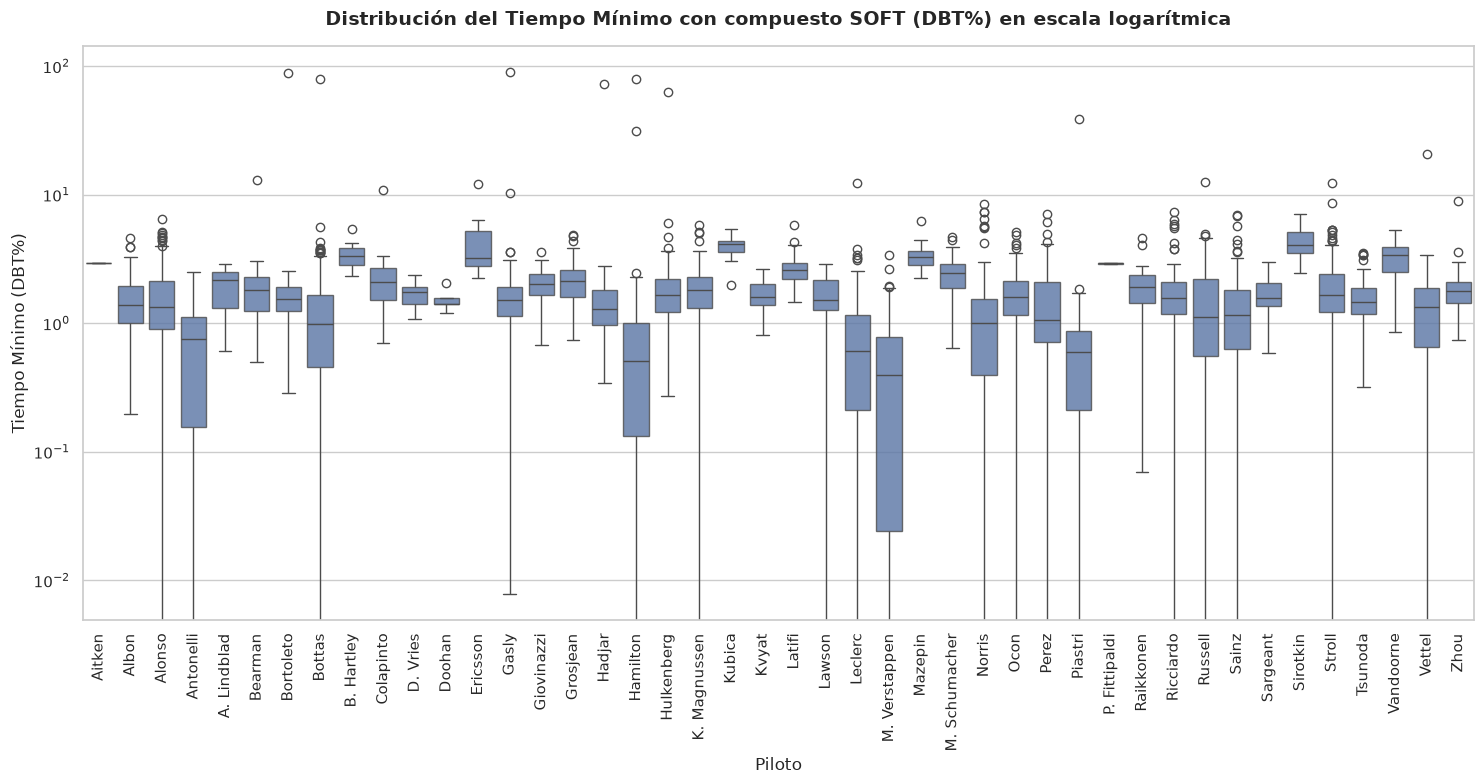

In [62]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8)) # Aumentar el tamaño para mejor visualización

# Plot de cajas (Boxplot) por Piloto y tiempo mínimo con compuesto SOFT (DBT%)
ax = sns.boxplot(
    data=df, # Usar el DataFrame filtrado
    x="DriverId_Cleaned", # Usar la columna de nombres limpios con inicial
    y="FP_LapTime_min_SOFT_DBT_%",
    boxprops=dict(alpha=0.8),
)
ax.set_yscale("log") # Escala logarítmica para mejorar la visualización
ax.set_ylabel("Tiempo Mínimo (DBT%)")
ax.set_xlabel("Piloto")
ax.set_title("Distribución del Tiempo Mínimo con compuesto SOFT (DBT%) en escala logarítmica", fontsize=14, fontweight="bold", pad=15)

plt.xticks(rotation=90) # Rotar las etiquetas del eje x para mejor legibilidad

plt.tight_layout()
plt.show()

### Boxplot de Distribución del Tiempo Mínimo con compuesto SOFT (DBT%) por Escudería

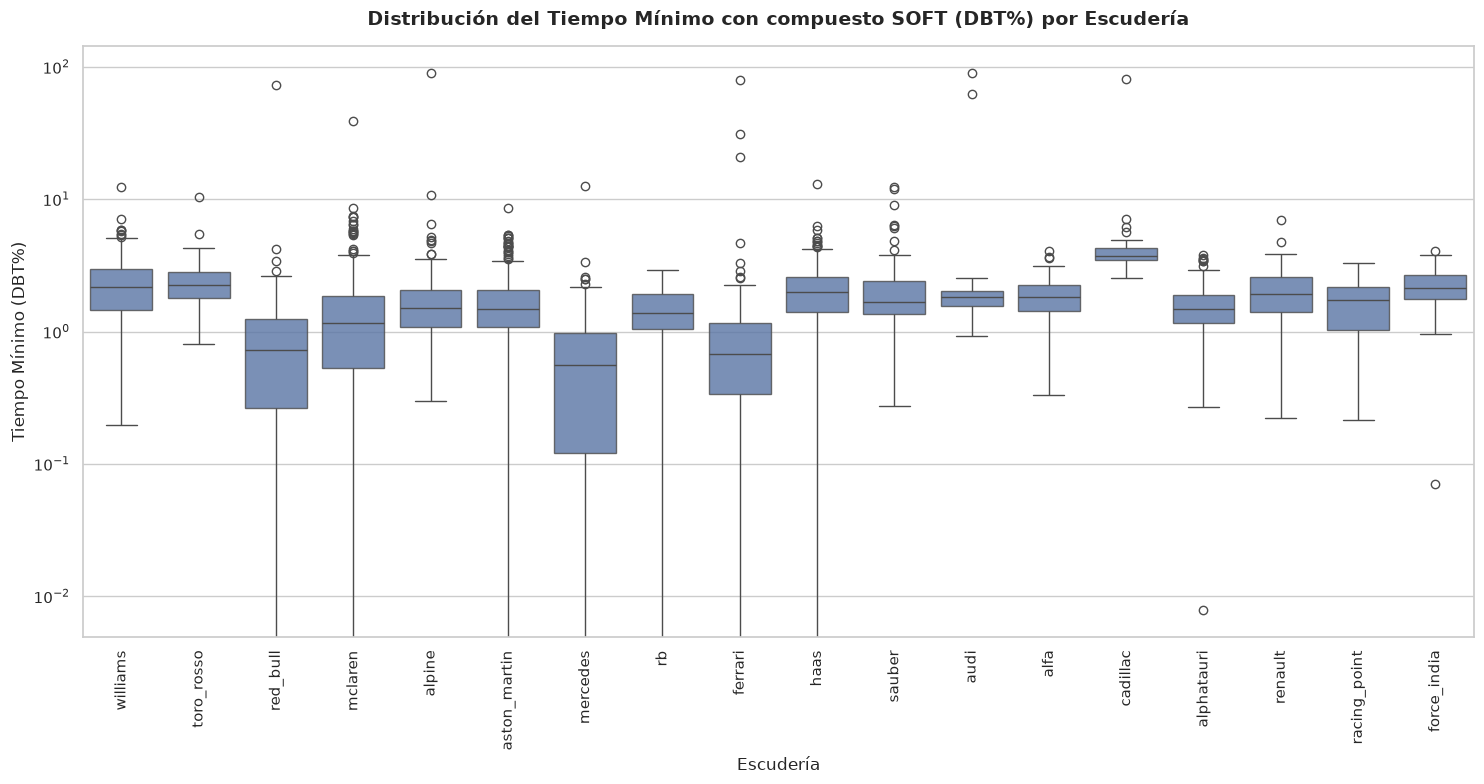

In [63]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8))

# Boxplot del tiempo mínimo con SOFT (DBT%) por escudería
ax = sns.boxplot(
    data=df,
    x="TeamId",
    y="FP_LapTime_min_SOFT_DBT_%",
    boxprops=dict(alpha=0.8),
)
ax.set_yscale("log") # Escala logarítmica para mejorar la visualización
ax.set_ylabel("Tiempo Mínimo (DBT%)")
ax.set_xlabel("Escudería")
ax.set_title("Distribución del Tiempo Mínimo con compuesto SOFT (DBT%) por Escudería", fontsize=14, fontweight="bold", pad=15)

plt.xticks(rotation=90) # Rotar las etiquetas del eje x para mejor legibilidad

plt.tight_layout()
plt.show()

### Comparación de Tiempo Mínimo con SOFT (DBT%) entre Compañeros de Equipo: Sainz vs. Leclerc

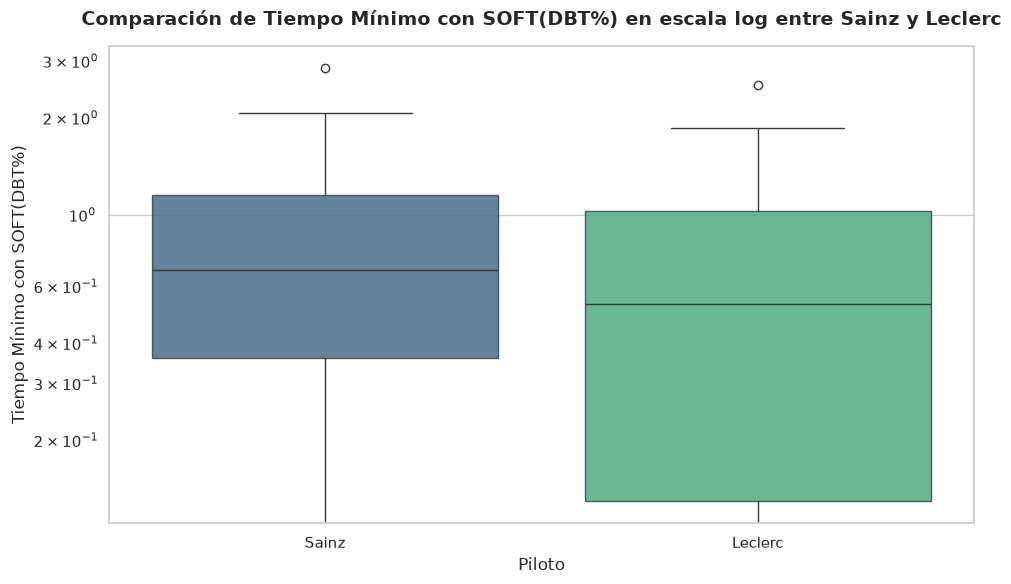

In [64]:
# Filtrar el DataFrame para los pilotos específicos (Sainz y Leclerc)
drivers_to_compare = ['Sainz', 'Leclerc']
df_sainz_leclerc = df[df['DriverId_Cleaned'].isin(drivers_to_compare)].copy()

# Identificar las combinaciones de Año y Ronda donde ambos pilotos compitieron
# Agrupar por Año y Ronda, y contar el número de pilotos únicos.
# Si el count es 2, significa que ambos estuvieron en esa carrera.
races_both_participated = df_sainz_leclerc.groupby(['Year', 'RoundNumber'])['DriverId_Cleaned'].nunique()
races_with_both = races_both_participated[races_both_participated == 2].index.tolist()

# Ahora, para estas carreras, necesitamos asegurarnos de que estaban en el mismo equipo.
teammate_data_indices = []
for year, round_num in races_with_both:
    # Obtener datos para esta carrera específica para ambos pilotos
    race_data = df_sainz_leclerc[
        (df_sainz_leclerc['Year'] == year) &
        (df_sainz_leclerc['RoundNumber'] == round_num)
    ]

    # Comprobar si su TeamId es el mismo en esta carrera
    if race_data['TeamId'].nunique() == 1: # Si solo hay un TeamId único, fueron compañeros de equipo
        teammate_data_indices.extend(race_data.index.tolist())

# Filtrar el DataFrame de comparación para incluir solo los datos de compañeros de equipo
df_teammates_comparison = df_sainz_leclerc.loc[list(set(teammate_data_indices))].copy()

# Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6)) # Tamaño de figura ajustado

# Plot de cajas (Boxplot) para la comparación
ax = sns.boxplot(
    data=df_teammates_comparison,
    x="DriverId_Cleaned",
    y="FP_LapTime_min_SOFT_DBT_%",
    boxprops=dict(alpha=0.8),
    hue="DriverId_Cleaned",
    palette="viridis",
    legend=False
)
ax.set_yscale("log") # Escala logarítmica para mejorar la visualización
ax.set_ylabel("Tiempo Mínimo con SOFT(DBT%)")
ax.set_xlabel("Piloto")

plt.title("Comparación de Tiempo Mínimo con SOFT(DBT%) en escala log entre Sainz y Leclerc", fontsize=14, fontweight="bold", pad=15)

plt.xticks(rotation=0) # No es necesario rotar si son pocos pilotos

plt.tight_layout()
plt.show()

### Comparación entre Sainz y Leclerc

Al comparar los tiempos mínimos con SOFT(DBT%) en escala log (FP_LapTime_min_SOFT_DBT_%) de **Sainz** y **Leclerc** de la misma escudería, podemos observar lo siguiente:

*   **Rangos Similares:** A primera vista, ambos pilotos muestran distribuciones de tiempos de vuelta con rangos muy similares, lo cual es esperable para compañeros de equipo que comparten el mismo coche y tienen estilos de conducción de alto nivel.
*   **Medianas Cercanas:** Las medianas de ambos boxplots están muy próximas, lo que sugiere que su tiempo de vuelta "típico" o más frecuente en las sesiones de prácticas es muy parecido.
*   **Consistencia Relativa:** Las cajas de ambos boxplots tienen longitudes comparables, indicando una consistencia similar en sus respectivos tiempos de vuelta. Ninguno de los dos parece ser significativamente más inconsistente que el otro en sus tiempos durante estas sesiones.
*   **Valores Atípicos:** Ambos pilotos presentan algunos valores atípicos, que podrían ser el resultado de vueltas específicas, errores, o pruebas de límites. Sin embargo, la presencia y distribución de estos atípicos no sugieren una diferencia fundamental en su comportamiento general en los tiempos.

En resumen, este análisis visual sugiere que, en cuanto al tiempo mínimo de vuelta con SOFT (DBT%), Sainz y Leclerc demuestran un rendimiento y una consistencia muy similares, lo cual refuerza la idea de que son pilotos de alto calibre en la misma máquina.

In [65]:
# Análisis la variable categórica 'TeamId'
tabla_frecuencias = pd.DataFrame(
    {
        "Frecuencia (N°)": df["TeamId"].value_counts(),
        "Proporción": df["TeamId"].value_counts(normalize=True).round(3),
        "Porcentaje (%)": (
            df["TeamId"].value_counts(normalize=True) * 100
        ).round(1),
    }
)

# Opcional: Renombrar el índice para dejarlo prolijo
tabla_frecuencias.index.name = "Escudería"
display(tabla_frecuencias)

,Frecuencia (N°),Proporción,Porcentaje (%)
Escudería,,,
williams,374,0.100,10.0
haas,374,0.100,10.0
red_bull,373,0.099,9.9
mclaren,373,0.099,9.9
ferrari,373,0.099,9.9
mercedes,372,0.099,9.9
alpine,254,0.068,6.8
aston_martin,253,0.067,6.7
alfa,208,0.055,5.5


In [66]:
# Las escuderías con menos corredores en el dataset
df["TeamId"].value_counts().tail(5)

TeamId
toro_rosso      84
racing_point    76
force_india     42
audi            26
cadillac        26
Name: count, dtype: int64